In [1]:
# # System libraries required by OpenCV (for libGL etc.)
# import subprocess
# def apt_install(pkgs):
#     subprocess.check_call(["apt", "update"])
#     subprocess.check_call(["apt", "install", "-y", *pkgs])

# pkgs = ["libgl1", "libglib2.0-0", "libsm6", "libxrender1", "libxext6"]
# print("Installing system packages:", pkgs)
# apt_install(pkgs)
# print("System packages installed. Please Restart Kernel before running imports.")

In [2]:
# # Install compatible packages (Option A: stay on NumPy 2.x)
# import sys, subprocess

# def run(cmd: list):
#     print("Running:", " ".join(cmd))
#     subprocess.check_call(cmd)

# # Pin NumPy to a 2.x release and OpenCV to a compatible wheel
# run([sys.executable, "-m", "pip", "install", "-U", "numpy>=2,<2.3"]) 
# run([sys.executable, "-m", "pip", "install", "-U", "--no-cache-dir", "--force-reinstall", "opencv-python==4.12.0.88"]) 

# # Force-reinstall retina-face so it resolves against the current ABI
# run([sys.executable, "-m", "pip", "install", "-U", "--no-cache-dir", "--force-reinstall", "retina-face"]) 

# print("Packages installed. Please Restart Kernel before running imports.")

# RetinaFace Quick Test

This notebook follows the official RetinaFace README for a minimal setup and applies Option A (stay on NumPy 2.x with compatible wheels):

- Install `numpy>=2,<2.3`, `opencv-python==4.12.0.88`, and force-reinstall `retina-face` (Cell 1)
- Restart the kernel to load new shared libraries
- Import and verify versions (Cell 2)
- Run `RetinaFace.detect_faces(img_path)` on a few images from the random testset
- Visualize detections with simple PIL drawing

In [4]:
# Minimal imports per README + version verification
import os, json, random
from datetime import datetime
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

import numpy as np
# import cv2
print("NumPy:", np.__version__)

from retinaface import RetinaFace

print("Imports OK")

NumPy: 2.2.6


2025-12-26 02:00:55.086404: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.12/dist-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



/usr/local/lib/python3.12/dist-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.12/dist-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 1075, in launc

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



ImportError: numpy.core.multiarray failed to import

In [ ]:
# Config: paths and output dir
BASE_DIR = "/app"  # workspace root
TESTSET_PATH = os.path.join(BASE_DIR, "testsets", "random_testset.json")
SAMPLE_SIZE = 5  # keep minimal for quick test

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
OUTPUT_DIR = os.path.join(BASE_DIR, "image_outputs", f"{timestamp}_retina_face_minimal_test")
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Config:")
print({
    "TESTSET_PATH": TESTSET_PATH,
    "SAMPLE_SIZE": SAMPLE_SIZE,
    "OUTPUT_DIR": OUTPUT_DIR
})

Config:
{'TESTSET_PATH': '/app/testsets/random_testset.json', 'SAMPLE_SIZE': 20, 'OUTPUT_DIR': '/app/image_outputs/20251226_012830_retina_face_random_test'}


In [ ]:
# Load testset and sample image paths

def load_random_testset(testset_path: str):

    with open(testset_path, "r") as f:

        entries = json.load(f)

    # normalize to absolute paths

    for e in entries:

        rel_path = e.get("path")

        e["abs_path"] = os.path.join(BASE_DIR, rel_path)

    return entries



def sample_entries(entries, n: int):

    valid = [e for e in entries if os.path.exists(e["abs_path"])]

    if len(valid) == 0:

        print("No valid image paths found. Check TESTSET_PATH and image locations.")

        return []

    if n >= len(valid):

        return valid

    return random.sample(valid, n)



entries = load_random_testset(TESTSET_PATH)

sampled = sample_entries(entries, SAMPLE_SIZE)

print(f"Loaded {len(entries)} entries; sampled {len(sampled)} valid images.")

print("Example:", sampled[0]["abs_path"] if sampled else None)

Loaded 54 entries; sampled 20 valid images.
Example: /app/Images/random Testset/Hugh Jackman/LP_4717652.jpg


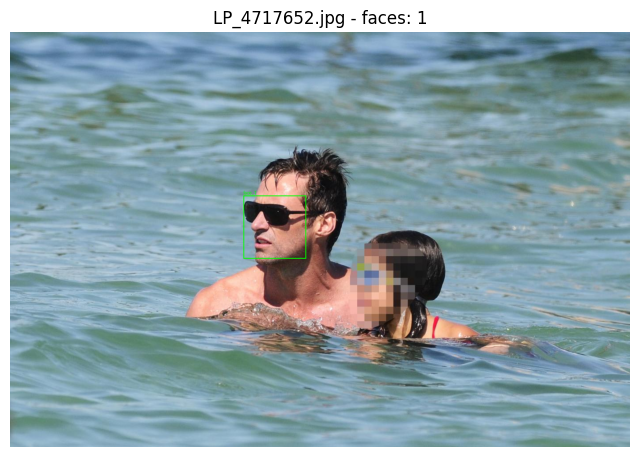

In [ ]:
# Minimal RetinaFace detection + visualization
def detect_retina(image_path: str):
    faces = RetinaFace.detect_faces(img_path=image_path)
    return faces
def annotate_pil(image: Image.Image, faces_dict):
    ann = image.copy()
    draw = ImageDraw.Draw(ann)
    if faces_dict not in (None, False):
        for k, v in faces_dict.items():
            box = v.get("facial_area")
            if box and len(box) == 4:
                x1, y1, x2, y2 = box
                draw.rectangle([x1, y1, x2, y2], outline=(0,255,0), width=2)
                draw.text((x1, max(0, y1 - 12)), k, fill=(0,255,0))
    return ann
def show(img: Image.Image, title: str = None):
    plt.figure(figsize=(8,6))
    plt.imshow(img)
    plt.axis('off')
    if title:
        plt.title(title)
    plt.show()

# Visualize first sampled image
if sampled:
    sp = sampled[0]["abs_path"]
    img = Image.open(sp).convert("RGB")
    faces = detect_retina(sp)
    count = 0 if faces in (None, False) else len(faces)
    ann = annotate_pil(img, faces)
    show(ann, title=f"{os.path.basename(sp)} - faces: {count}")
else:
    print("No sampled images.")

In [ ]:
# Minimal loop over small sample
for e in sampled[:SAMPLE_SIZE]:
    path = e["abs_path"]
    img = Image.open(path).convert("RGB")
    faces = detect_retina(path)
    count = 0 if faces in (None, False) else len(faces)
    ann = annotate_pil(img, faces)
    show(ann, title=f"{os.path.basename(path)} - faces: {count}")